<a href="https://colab.research.google.com/github/carolinecorley13-lab/L3-Data-Analysis-TE/blob/main/CC13%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Cleaning and Transformation in pandas
# Data Aggregation in pandas
# Data summarisation in pandas (group by)


In [ ]:
# upload dataset into a storage session
# import pandas library

import pandas as pd

In [ ]:
#ingest/import our data to pandas
mydata = pd.read_csv("/content/F6 sales_data_sample.csv", encoding ="latin-1")

In [ ]:
# number of rows and columns in the dataset
mydata.shape

(2823, 25)

In [ ]:
# check for basic statistics of all numerical columns
mydata.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [ ]:
# data cleaning what are tasks that you look out for?
# missing values
# outliers
#duplicate values
# case inconsistencies
# wrong data type

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# missing values
mydata.isnull().sum()

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [ ]:
#check for case incosistency in City, State, Territory and Country

mydata['CITY'].unique()

array(['NYC', 'Reims', 'Paris', 'Pasadena', 'San Francisco', 'Burlingame',
       'Lille', 'Bergen', 'Melbourne', 'Newark', 'Bridgewater', 'Nantes',
       'Cambridge', 'Helsinki', 'Stavern', 'Allentown', 'Salzburg',
       'Chatswood', 'New Bedford', 'Liverpool', 'Madrid', 'Lule',
       'Singapore', 'South Brisbane', 'Philadelphia', 'Lyon', 'Vancouver',
       'Burbank', 'New Haven', 'Minato-ku', 'Torino', 'Boras',
       'Versailles', 'San Rafael', 'Nashua', 'Brickhaven', 'North Sydney',
       'Montreal', 'Osaka', 'White Plains', 'Kobenhavn', 'London',
       'Toulouse', 'Barcelona', 'Los Angeles', 'San Diego', 'Bruxelles',
       'Tsawassen', 'Boston', 'Cowes', 'Oulu', 'San Jose', 'Graz',
       'Makati City', 'Marseille', 'Koln', 'Gensve', 'Reggio Emilia',
       'Frankfurt', 'Espoo', 'Dublin', 'Manchester', 'Aaarhus',
       'Glendale', 'Sevilla', 'Brisbane', 'Strasbourg', 'Las Vegas',
       'Oslo', 'Bergamo', 'Glen Waverly', 'Munich', 'Charleroi'],
      dtype=object)

In [ ]:
mydata['STATE'].unique()

array(['NY', nan, 'CA', 'Victoria', 'NJ', 'CT', 'MA', 'PA', 'NSW',
       'Queensland', 'BC', 'Tokyo', 'NH', 'Quebec', 'Osaka',
       'Isle of Wight', 'NV'], dtype=object)

In [ ]:
mydata['COUNTRY'].unique()

array(['USA', 'FranCe', 'France', 'Norway', 'usa', 'FrancE', 'Australia',
       'Finland', 'NorwaY', 'Austria', '       Australia', 'UK', 'Spain',
       'Sweden', 'Singapore', 'Canada', 'Japan', 'Italy', '      Sweden',
       'Denmark', 'Belgium', 'Philippines', 'Germany', 'Switzerland',
       'Ireland'], dtype=object)

In [ ]:
mydata.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [ ]:
# concatenate the addressline1 and addressline 2, into full address
mydata["Full Address"] = mydata['ADDRESSLINE1'].str.cat(mydata['ADDRESSLINE2'],sep=" ",na_rep=' ').str.strip()
# concatenate contactlastname(2) and contact firstname(1) into full name
mydata["Full Name"] = mydata['CONTACTFIRSTNAME'].str.cat(mydata['CONTACTLASTNAME'], sep=" ")


In [ ]:
mydata.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE', 'Full Address', 'Full Name'],
      dtype='object')

In [ ]:
#drop columns not needed - addressline1,2, contact first and lastname

mydata.drop(columns=['ADDRESSLINE1', 'ADDRESSLINE2','CONTACTLASTNAME', 'CONTACTFIRSTNAME'], inplace=True)

In [ ]:
mydata.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'CITY',
       'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'DEALSIZE',
       'Full Address', 'Full Name'],
      dtype='object')

In [ ]:
mydata.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CUSTOMERNAME,PHONE,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,DEALSIZE,Full Address,Full Name
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,Land of Toys Inc.,2125557818,NYC,NY,10022,USA,NaN,Small,897 Long Airport Avenue,Kwai Yu
1,10121,34,81.35,5,2765.90,05/07/2003 00:00,Shipped,2,5,2003,...,Reims Collectables,26.47.1555,Reims,NaN,51100,FranCe,emea,Small,59 rue de l'Abbaye,Paul Henriot
2,10134,41,94.74,2,3884.34,07/01/2003 00:00,Shipped,3,7,2003,...,Lyon Souveniers,+33 1 46 62 7555,Paris,NaN,75508,France,emea,Medium,27 rue du Colonel Pierre Avia,Daniel Da Cunha
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,Toys4GrownUps.com,6265557265,Pasadena,CA,90003,USA,NaN,Medium,78934 Hillside Dr.,Julie Young
4,10159,49,100.00,14,5205.27,10/10/2003 00:00,Shipped,4,10,2003,...,Corporate Gift Ideas Co.,6505551386,San Francisco,CA,NaN,USA,NaN,Medium,7734 Strong St.,Julie Brown


In [ ]:
#change the column title from upper cases to title case

# lower case -> customer name
# upper case -> CUSTOMER NAME
# title case -> Customer Name
# capitalize case -> Customer name

mydata.columns=mydata.columns.str.title()
mydata.columns

Index(['Ordernumber', 'Quantityordered', 'Priceeach', 'Orderlinenumber',
       'Sales', 'Orderdate', 'Status', 'Qtr_Id', 'Month_Id', 'Year_Id',
       'Productline', 'Msrp', 'Productcode', 'Customername', 'Phone', 'City',
       'State', 'Postalcode', 'Country', 'Territory', 'Dealsize',
       'Full Address', 'Full Name'],
      dtype='object')

In [ ]:
# standadise COUNTRY case and remove leading and trailing spaces
mydata['Country'].unique() #before transformation

array(['USA', 'FranCe', 'France', 'Norway', 'usa', 'FrancE', 'Australia',
       'Finland', 'NorwaY', 'Austria', '       Australia', 'UK', 'Spain',
       'Sweden', 'Singapore', 'Canada', 'Japan', 'Italy', '      Sweden',
       'Denmark', 'Belgium', 'Philippines', 'Germany', 'Switzerland',
       'Ireland'], dtype=object)

In [ ]:
mydata['Country']= mydata['Country'].str.title().str.strip()
mydata['Country'].unique() #after first transformation

array(['Usa', 'France', 'Norway', 'Australia', 'Finland', 'Austria', 'Uk',
       'Spain', 'Sweden', 'Singapore', 'Canada', 'Japan', 'Italy',
       'Denmark', 'Belgium', 'Philippines', 'Germany', 'Switzerland',
       'Ireland'], dtype=object)

In [ ]:
# replace Usa - USA and Uk with UK
mydata['Country'].replace({'Usa':'USA','Uk':'UK'},inplace=True)
mydata['Country'].unique() #sencond transformation on Country

/tmp/ipykernel_1159/3271075054.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mydata['Country'].replace({'Usa':'USA','Uk':'UK'},inplace=True)


array(['USA', 'France', 'Norway', 'Australia', 'Finland', 'Austria', 'UK',
       'Spain', 'Sweden', 'Singapore', 'Canada', 'Japan', 'Italy',
       'Denmark', 'Belgium', 'Philippines', 'Germany', 'Switzerland',
       'Ireland'], dtype=object)

In [ ]:
# replace Nan in Territory with 'NA' using fillna()

mydata['Territory'].unique()  #before transformation


array([nan, 'emea', 'EMEA', 'APAc', 'APAC', 'EMEa', 'Japan'], dtype=object)

In [ ]:
mydata['Territory'] = mydata['Territory'].fillna('NA')
mydata['Territory'].unique() #after replacing missing values

array(['NA', 'emea', 'EMEA', 'APAc', 'APAC', 'EMEa', 'Japan'],
      dtype=object)

In [ ]:
# change Territory case to upper case
mydata['Territory']= mydata['Territory'].str.upper()
mydata['Territory'].unique() # after case transformation

array(['NA', 'EMEA', 'APAC', 'JAPAN'], dtype=object)

In [ ]:
#checking data from yesterday above. New stuff below.

mydata.head()


,Ordernumber,Quantityordered,Priceeach,Orderlinenumber,Sales,Orderdate,Status,Qtr_Id,Month_Id,Year_Id,...,Customername,Phone,City,State,Postalcode,Country,Territory,Dealsize,Full Address,Full Name
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,Land of Toys Inc.,2125557818,NYC,NY,10022,USA,NA,Small,897 Long Airport Avenue,Kwai Yu
1,10121,34,81.35,5,2765.90,05/07/2003 00:00,Shipped,2,5,2003,...,Reims Collectables,26.47.1555,Reims,NaN,51100,France,EMEA,Small,59 rue de l'Abbaye,Paul Henriot
2,10134,41,94.74,2,3884.34,07/01/2003 00:00,Shipped,3,7,2003,...,Lyon Souveniers,+33 1 46 62 7555,Paris,NaN,75508,France,EMEA,Medium,27 rue du Colonel Pierre Avia,Daniel Da Cunha
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,Toys4GrownUps.com,6265557265,Pasadena,CA,90003,USA,NA,Medium,78934 Hillside Dr.,Julie Young
4,10159,49,100.00,14,5205.27,10/10/2003 00:00,Shipped,4,10,2003,...,Corporate Gift Ideas Co.,6505551386,San Francisco,CA,NaN,USA,NA,Medium,7734 Strong St.,Julie Brown


In [ ]:
mydata.shape

(2823, 23)

In [ ]:
# the changed data can be saved by writing to file

mydata.to_csv("cleaned_sales_data.csv", index=False)


In [ ]:
#ingest/import the cleaned data to pandas for analysis

dataDF = pd.read_csv("/content/cleaned_sales_data.csv", encoding ="latin-1")


In [ ]:
dataDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ordernumber      2823 non-null   int64  
 1   Quantityordered  2823 non-null   int64  
 2   Priceeach        2823 non-null   float64
 3   Orderlinenumber  2823 non-null   int64  
 4   Sales            2823 non-null   float64
 5   Orderdate        2823 non-null   object 
 6   Status           2823 non-null   object 
 7   Qtr_Id           2823 non-null   int64  
 8   Month_Id         2823 non-null   int64  
 9   Year_Id          2823 non-null   int64  
 10  Productline      2823 non-null   object 
 11  Msrp             2823 non-null   int64  
 12  Productcode      2823 non-null   object 
 13  Customername     2823 non-null   object 
 14  Phone            2823 non-null   object 
 15  City             2823 non-null   object 
 16  State            1337 non-null   object 
 17  Postalcode    

In [ ]:
# SUM of column, use same formats for descriptive stats
# use with count, min etc

dataDF['Sales'].sum()
print("The total sales are", dataDF['Sales'].sum())


The total sales are 10032628.85


In [ ]:
# alternative version using f' {} and putting , between currrency

ts = total_sales = dataDF['Sales'].sum()
print(f'The total sales is {ts:,}')


The total sales is 10,032,628.85


In [ ]:
cs = count_sales = dataDF['Sales'].count()
print(f'The number of orders is {cs:,}')

The number of orders is 2,823


In [ ]:
# Group one column by another

ysales = dataDF.groupby('Year_Id')['Sales'].sum()


In [ ]:
# group multiple columns and sort descending

csales = dataDF.groupby('Country')[['Quantityordered','Sales']].sum().sort_values ('Sales', ascending = False)
print (csales)

             Quantityordered       Sales
Country                                 
USA                    35659  3627982.83
Spain                  12429  1215686.92
France                 11090  1110916.52
Australia               6246   630623.10
UK                      5013   478880.46
Italy                   3773   374674.31
Finland                 3192   329581.91
Norway                  2842   307463.70
Singapore               2760   288488.41
Denmark                 2197   245637.15
Canada                  2293   224078.56
Germany                 2148   220472.09
Sweden                  2006   210014.21
Austria                 1974   202062.53
Japan                   1842   188167.81
Switzerland             1078   117713.56
Belgium                 1074   108412.62
Philippines              961    94015.73
Ireland                  490    57756.43


In [ ]:
# view head of new sorted data

csales.head()

,Quantityordered,Sales
Country,,
USA,35659,3627982.83
Spain,12429,1215686.92
France,11090,1110916.52
Australia,6246,630623.10
UK,5013,478880.46


In [ ]:
# visualisation import matplotlib

import matplotlib.pyplot as plt


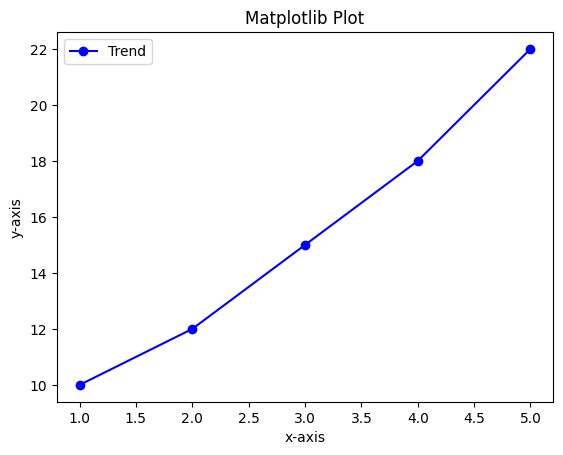

In [ ]:
# creating scatter plot
x = [1,2,3,4,5]
y = [10,12,15,18,22]

plt.plot (x,y, marker = 'o', linestyle = '-', color = 'blue', label = 'Trend')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('Matplotlib Plot')
plt.legend()
plt.show()

<Axes: ylabel='Sales'>

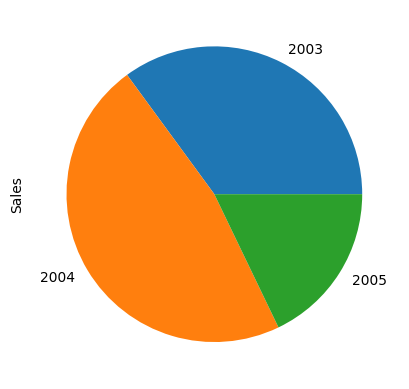

In [ ]:
#pie chart using our data

ysales.plot(x='Year_Id', y='Sales', kind= 'pie')

Text(0, 0.5, 'Total Sales')

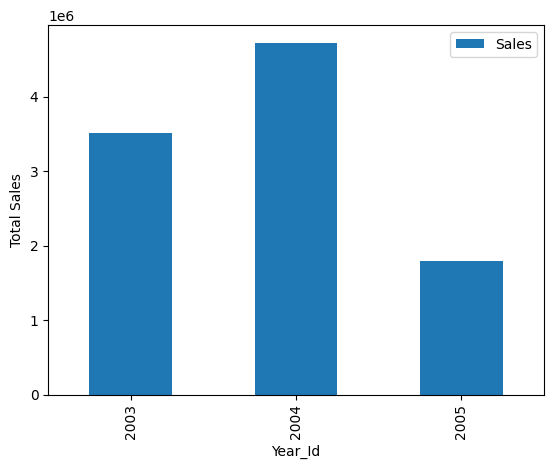

In [ ]:
# bar chart
ysales.plot(x='Year_Id', y='Sales', kind= 'bar')
plt.legend()
plt.ylabel('Total Sales')